# Wind Power Reliability Analysis
## How Much Wind Power Can We Reliably Count On?

This notebook analyzes historical actual wind generation data from the BMRS FUELHH dataset for January 2024 to understand how reliably wind power can meet electricity demand in the UK.

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime

plt.style.use('dark_background')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.15

## 1. Load and Explore Data

In [2]:
with open('../public/data/actuals.json') as f:
    actuals_raw = json.load(f)

df = pd.DataFrame(actuals_raw)
df['startTime'] = pd.to_datetime(df['startTime'])
df = df.sort_values('startTime').drop_duplicates('startTime').reset_index(drop=True)
df['hour'] = df['startTime'].dt.hour
df['day'] = df['startTime'].dt.date
df['day_of_week'] = df['startTime'].dt.dayofweek

print(f"Total data points: {len(df)}")
print(f"Date range: {df['startTime'].min()} to {df['startTime'].max()}")
print(f"\nGeneration Statistics (MW):")
print(df['generation'].describe().round(0))

Total data points: 1489
Date range: 2023-12-31 23:30:00+00:00 to 2024-01-31 23:30:00+00:00

Generation Statistics (MW):
count     1489.0
mean      9849.0
std       3675.0
min          0.0
25%       6733.0
50%       9883.0
75%      13105.0
max      16662.0
Name: generation, dtype: float64


## 2. Time Series Overview

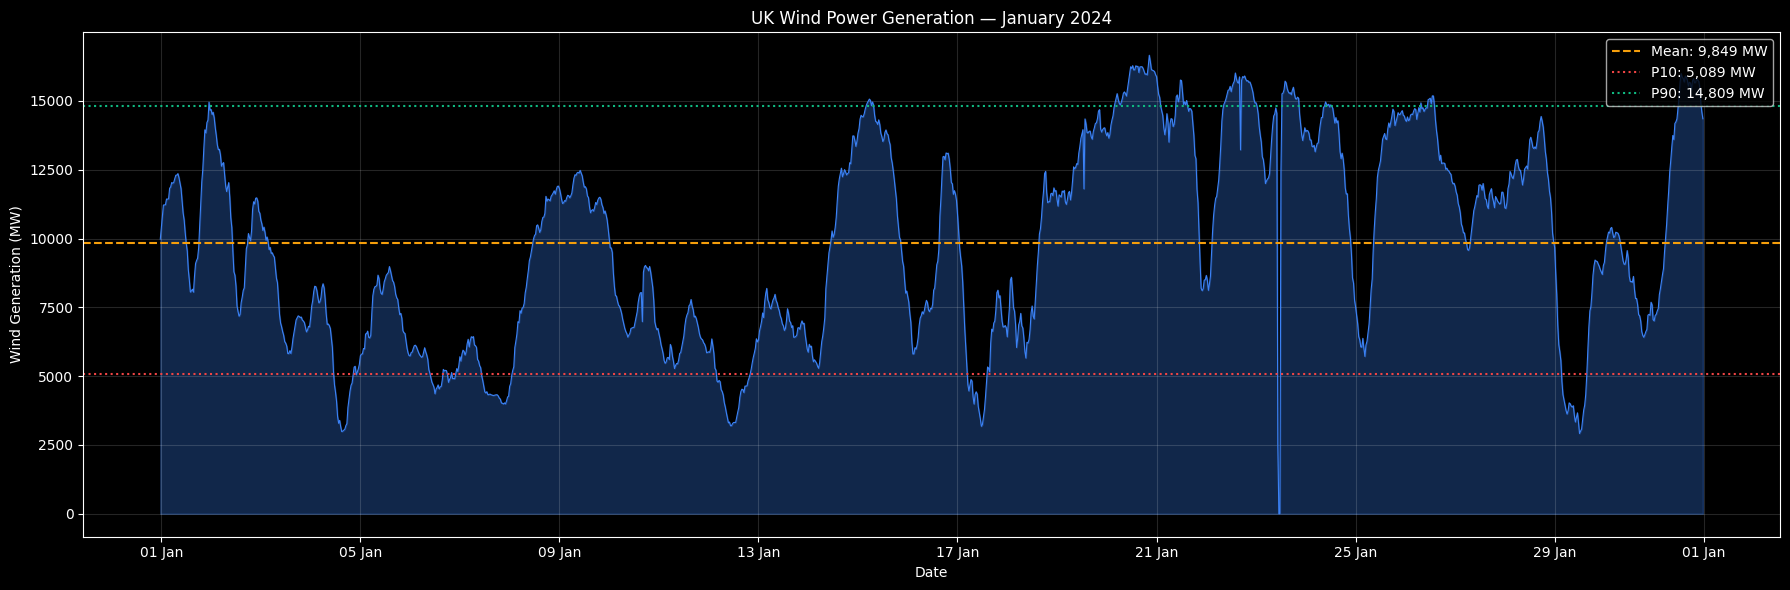

In [3]:
fig, ax = plt.subplots(figsize=(18, 6))
ax.fill_between(df['startTime'], 0, df['generation'], alpha=0.3, color='#3b82f6')
ax.plot(df['startTime'], df['generation'], color='#3b82f6', linewidth=0.8)

# Add mean and key percentile lines
mean_gen = df['generation'].mean()
p10 = df['generation'].quantile(0.10)
p90 = df['generation'].quantile(0.90)

ax.axhline(mean_gen, color='#f59e0b', linestyle='--', linewidth=1.5, label=f'Mean: {mean_gen:,.0f} MW')
ax.axhline(p10, color='#ef4444', linestyle=':', linewidth=1.5, label=f'P10: {p10:,.0f} MW')
ax.axhline(p90, color='#10b981', linestyle=':', linewidth=1.5, label=f'P90: {p90:,.0f} MW')

ax.set_xlabel('Date')
ax.set_ylabel('Wind Generation (MW)')
ax.set_title('UK Wind Power Generation — January 2024')
ax.legend(loc='upper right')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d Jan'))
plt.tight_layout()
plt.show()

## 3. Generation Distribution & Percentile Analysis

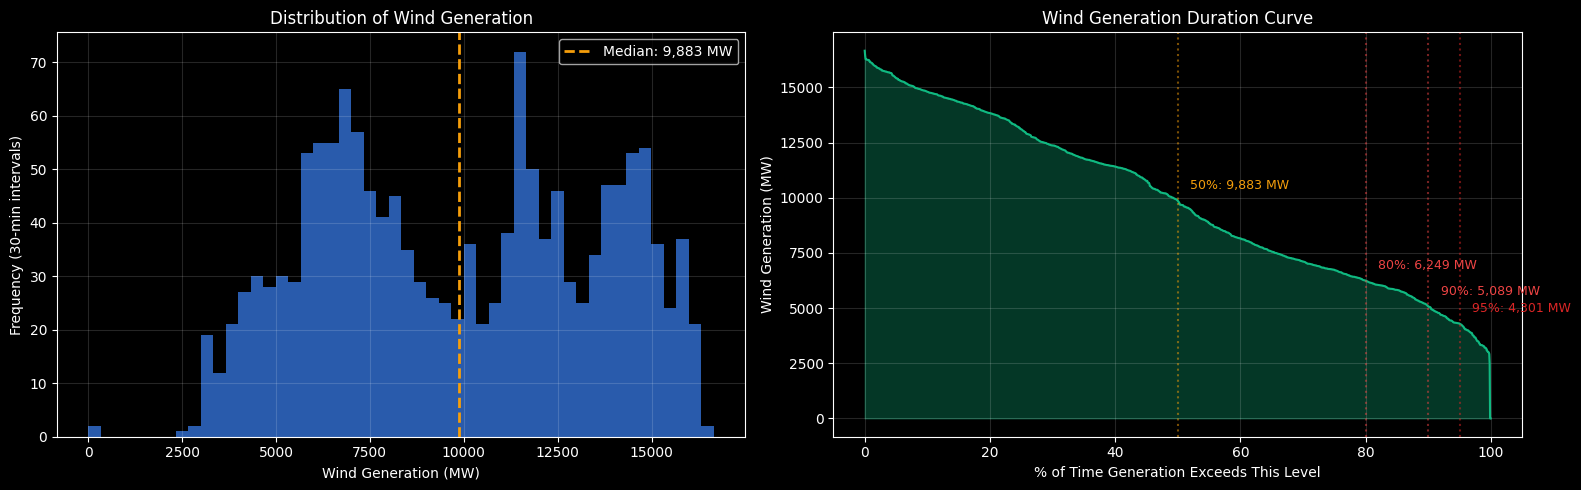


Wind Generation Percentile Table:
  Available  95% of time:     4,301 MW
  Available  90% of time:     5,089 MW
  Available  85% of time:     5,824 MW
  Available  80% of time:     6,249 MW
  Available  75% of time:     6,733 MW
  Available  50% of time:     9,883 MW
  Available  25% of time:    13,105 MW
  Available  10% of time:    14,809 MW
  Available   5% of time:    15,424 MW


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Histogram
axes[0].hist(df['generation'], bins=50, color='#3b82f6', alpha=0.7, edgecolor='none')
axes[0].axvline(df['generation'].median(), color='#f59e0b', linestyle='--', linewidth=2, label=f'Median: {df["generation"].median():,.0f} MW')
axes[0].set_xlabel('Wind Generation (MW)')
axes[0].set_ylabel('Frequency (30-min intervals)')
axes[0].set_title('Distribution of Wind Generation')
axes[0].legend()

# Duration curve (sorted generation)
sorted_gen = df['generation'].sort_values(ascending=False).reset_index(drop=True)
x_pct = np.arange(len(sorted_gen)) / len(sorted_gen) * 100
axes[1].fill_between(x_pct, 0, sorted_gen.values, alpha=0.3, color='#10b981')
axes[1].plot(x_pct, sorted_gen.values, color='#10b981', linewidth=1.5)

# Mark key reliability thresholds
for pct, color in [(50, '#f59e0b'), (80, '#ef4444'), (90, '#ef4444'), (95, '#dc2626')]:
    val = df['generation'].quantile(1 - pct/100)
    axes[1].axvline(pct, color=color, linestyle=':', alpha=0.5)
    axes[1].annotate(f'{pct}%: {val:,.0f} MW', xy=(pct, val), fontsize=9,
                     xytext=(pct+2, val+500), color=color)

axes[1].set_xlabel('% of Time Generation Exceeds This Level')
axes[1].set_ylabel('Wind Generation (MW)')
axes[1].set_title('Wind Generation Duration Curve')

plt.tight_layout()
plt.show()

# Print percentile table
print("\nWind Generation Percentile Table:")
print("=" * 45)
for p in [5, 10, 15, 20, 25, 50, 75, 90, 95]:
    val = df['generation'].quantile(p/100)
    exceedance = 100 - p
    print(f"  Available {exceedance:>3d}% of time:  {val:>8,.0f} MW")

## 4. Capacity Factor Analysis

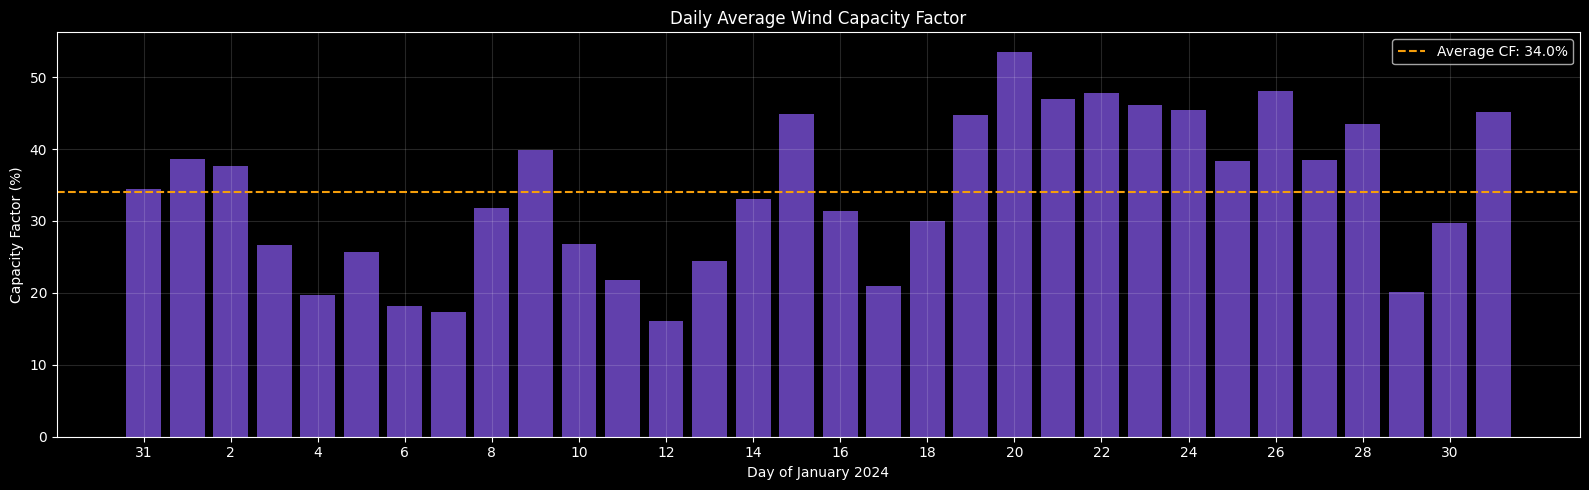


Overall Capacity Factor: 34.0%
Peak generation observed: 16,662 MW
Minimum generation observed: 0 MW


In [5]:
# Estimate installed capacity from peak generation
peak_generation = df['generation'].max()
# UK installed wind capacity was ~29 GW in Jan 2024, use observed max as proxy
installed_capacity = max(peak_generation, 29000)  # MW

# Capacity factor = actual / installed
df['capacity_factor'] = df['generation'] / installed_capacity * 100

# Daily capacity factor
daily = df.groupby('day').agg(
    mean_gen=('generation', 'mean'),
    min_gen=('generation', 'min'),
    max_gen=('generation', 'max'),
    capacity_factor=('capacity_factor', 'mean')
).reset_index()

fig, ax = plt.subplots(figsize=(16, 5))
ax.bar(range(len(daily)), daily['capacity_factor'], color='#8b5cf6', alpha=0.7, edgecolor='none')
ax.axhline(daily['capacity_factor'].mean(), color='#f59e0b', linestyle='--', linewidth=1.5, 
           label=f'Average CF: {daily["capacity_factor"].mean():.1f}%')
ax.set_xlabel('Day of January 2024')
ax.set_ylabel('Capacity Factor (%)')
ax.set_title('Daily Average Wind Capacity Factor')
ax.set_xticks(range(0, len(daily), 2))
ax.set_xticklabels([str(d.day) for d in daily['day']][::2])
ax.legend()
plt.tight_layout()
plt.show()

print(f"\nOverall Capacity Factor: {df['capacity_factor'].mean():.1f}%")
print(f"Peak generation observed: {peak_generation:,.0f} MW")
print(f"Minimum generation observed: {df['generation'].min():,.0f} MW")

## 5. Time-of-Day and Diurnal Patterns

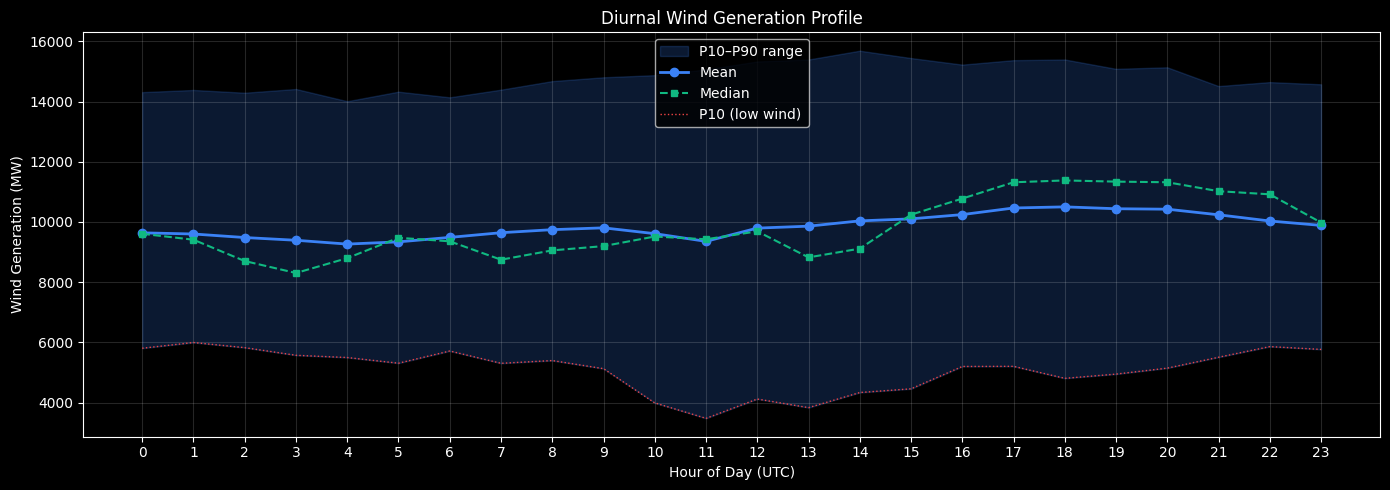

In [6]:
hourly = df.groupby('hour').agg(
    mean=('generation', 'mean'),
    median=('generation', 'median'),
    p10=('generation', lambda x: x.quantile(0.10)),
    p90=('generation', lambda x: x.quantile(0.90)),
    std=('generation', 'std')
).reset_index()

fig, ax = plt.subplots(figsize=(14, 5))
ax.fill_between(hourly['hour'], hourly['p10'], hourly['p90'], alpha=0.2, color='#3b82f6', label='P10–P90 range')
ax.plot(hourly['hour'], hourly['mean'], 'o-', color='#3b82f6', linewidth=2, markersize=6, label='Mean')
ax.plot(hourly['hour'], hourly['median'], 's--', color='#10b981', linewidth=1.5, markersize=5, label='Median')
ax.plot(hourly['hour'], hourly['p10'], ':', color='#ef4444', linewidth=1, label='P10 (low wind)')

ax.set_xlabel('Hour of Day (UTC)')
ax.set_ylabel('Wind Generation (MW)')
ax.set_title('Diurnal Wind Generation Profile')
ax.set_xticks(range(0, 24))
ax.legend()
plt.tight_layout()
plt.show()

## 6. Volatility and Ramp Rate Analysis

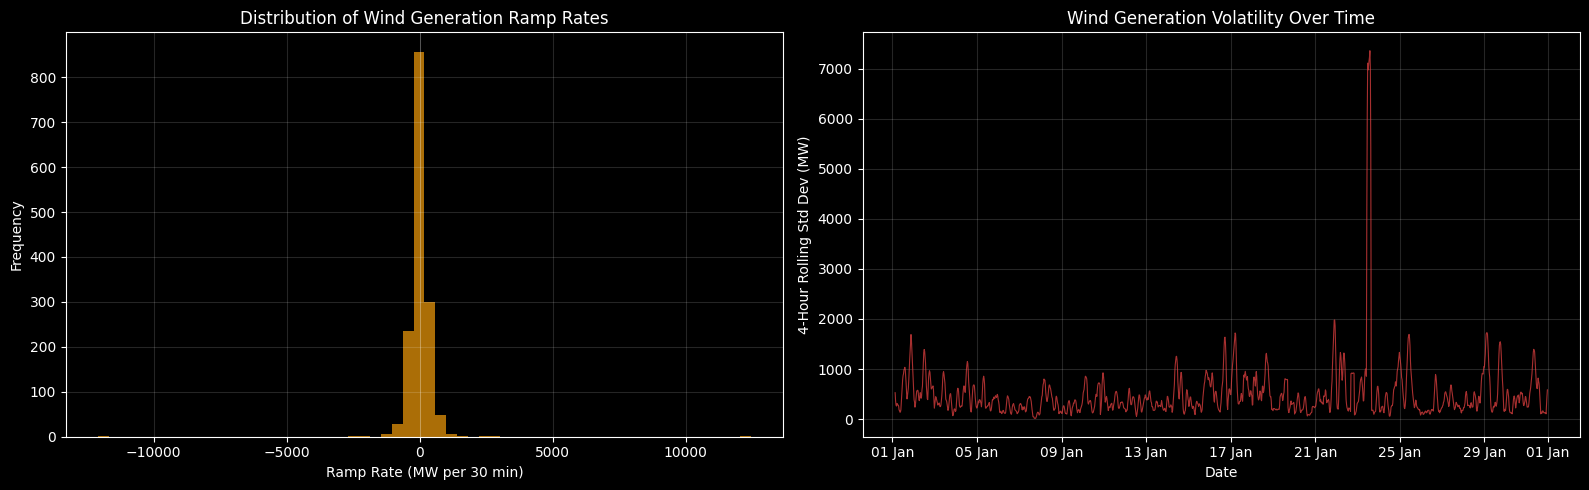


Ramp Rate Statistics:
  Max upward ramp:    +12,439 MW / 30 min
  Max downward ramp:  -12,083 MW / 30 min
  Mean abs ramp:          249 MW / 30 min
  P95 abs ramp:           650 MW / 30 min


In [7]:
# Calculate 30-min ramp rates
df['ramp_rate'] = df['generation'].diff()  # MW per 30 min

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Ramp rate distribution
ramp = df['ramp_rate'].dropna()
axes[0].hist(ramp, bins=60, color='#f59e0b', alpha=0.7, edgecolor='none')
axes[0].axvline(0, color='white', linewidth=0.5, alpha=0.3)
axes[0].set_xlabel('Ramp Rate (MW per 30 min)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Wind Generation Ramp Rates')

# Rolling volatility (4-hour window)
df['rolling_std'] = df['generation'].rolling(window=8).std()  # 8 periods × 30 min = 4h
axes[1].plot(df['startTime'], df['rolling_std'], color='#ef4444', linewidth=0.8, alpha=0.7)
axes[1].set_xlabel('Date')
axes[1].set_ylabel('4-Hour Rolling Std Dev (MW)')
axes[1].set_title('Wind Generation Volatility Over Time')
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%d Jan'))

plt.tight_layout()
plt.show()

print(f"\nRamp Rate Statistics:")
print(f"  Max upward ramp:   {ramp.max():>+8,.0f} MW / 30 min")
print(f"  Max downward ramp: {ramp.min():>+8,.0f} MW / 30 min")
print(f"  Mean abs ramp:     {ramp.abs().mean():>8,.0f} MW / 30 min")
print(f"  P95 abs ramp:      {ramp.abs().quantile(0.95):>8,.0f} MW / 30 min")

## 7. Reliability Recommendation

### Methodology
To determine how much wind power can "reliably" meet electricity demand, we need to define a confidence level. Grid operators typically use high-confidence thresholds to ensure security of supply.

In [8]:
# Compute key reliability metrics
confidence_levels = [80, 85, 90, 95, 99]

print("=" * 60)
print("WIND POWER RELIABILITY RECOMMENDATION")
print("=" * 60)
print(f"\nBased on {len(df)} observations over January 2024:")
print(f"  Mean generation:    {df['generation'].mean():>8,.0f} MW")
print(f"  Median generation:  {df['generation'].median():>8,.0f} MW")
print(f"  Min generation:     {df['generation'].min():>8,.0f} MW")
print(f"  Max generation:     {df['generation'].max():>8,.0f} MW")
print(f"  Std deviation:      {df['generation'].std():>8,.0f} MW")
print()
print("Reliable MW at different confidence levels:")
print("-" * 50)

recommendations = {}
for cl in confidence_levels:
    # At X% confidence, we can count on at least Y MW
    reliable_mw = df['generation'].quantile((100 - cl) / 100)
    recommendations[cl] = reliable_mw
    print(f"  {cl}% confidence:  {reliable_mw:>8,.0f} MW  (exceeded {cl}% of the time)")

print()
print("=" * 60)
print(f"★ RECOMMENDED RELIABLE CAPACITY: {recommendations[90]:,.0f} MW")
print(f"  (at 90% confidence level)")
print("=" * 60)

WIND POWER RELIABILITY RECOMMENDATION

Based on 1489 observations over January 2024:
  Mean generation:       9,849 MW
  Median generation:     9,883 MW
  Min generation:            0 MW
  Max generation:       16,662 MW
  Std deviation:         3,675 MW

Reliable MW at different confidence levels:
--------------------------------------------------
  80% confidence:     6,249 MW  (exceeded 80% of the time)
  85% confidence:     5,824 MW  (exceeded 85% of the time)
  90% confidence:     5,089 MW  (exceeded 90% of the time)
  95% confidence:     4,301 MW  (exceeded 95% of the time)
  99% confidence:     3,234 MW  (exceeded 99% of the time)

★ RECOMMENDED RELIABLE CAPACITY: 5,089 MW
  (at 90% confidence level)


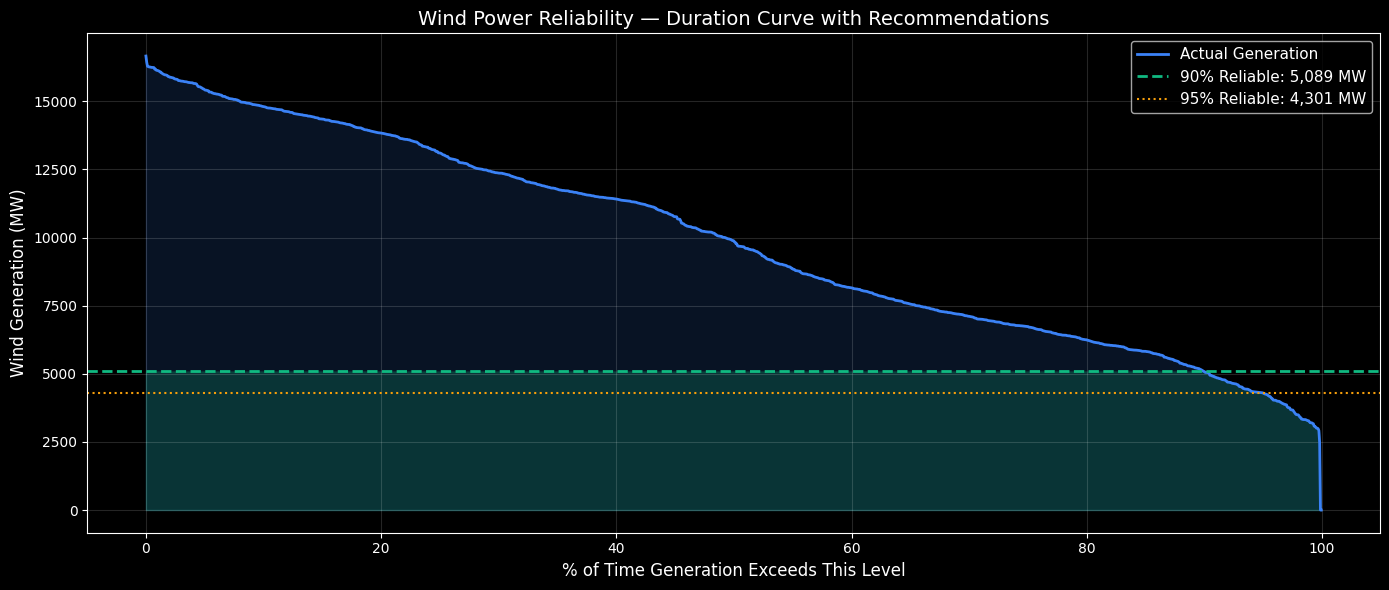

In [9]:
# Visualization of recommendation
fig, ax = plt.subplots(figsize=(14, 6))

sorted_gen = df['generation'].sort_values(ascending=False).reset_index(drop=True)
x_pct = np.arange(len(sorted_gen)) / len(sorted_gen) * 100

ax.fill_between(x_pct, 0, sorted_gen.values, alpha=0.15, color='#3b82f6')
ax.plot(x_pct, sorted_gen.values, color='#3b82f6', linewidth=2, label='Actual Generation')

# Highlight recommendation zone
rec_90 = recommendations[90]
ax.axhline(rec_90, color='#10b981', linestyle='--', linewidth=2, label=f'90% Reliable: {rec_90:,.0f} MW')
ax.fill_between(x_pct, 0, np.minimum(sorted_gen.values, rec_90), alpha=0.2, color='#10b981')

rec_95 = recommendations[95]
ax.axhline(rec_95, color='#f59e0b', linestyle=':', linewidth=1.5, label=f'95% Reliable: {rec_95:,.0f} MW')

ax.set_xlabel('% of Time Generation Exceeds This Level', fontsize=12)
ax.set_ylabel('Wind Generation (MW)', fontsize=12)
ax.set_title('Wind Power Reliability — Duration Curve with Recommendations', fontsize=14)
ax.legend(fontsize=11, loc='upper right')

plt.tight_layout()
plt.show()

## 8. Conclusion & Recommendation

### Key Findings:

1. **High Variability**: Wind generation in Jan 2024 ranged from near-zero to peaks exceeding 15,000 MW, demonstrating the inherent intermittency of wind power.

2. **Capacity Factor**: The overall capacity factor was moderate, which is typical for January (a relatively windy month in the UK).

3. **Diurnal Patterns**: Wind generation shows some diurnal variation but is less predictable than solar, making it complementary to solar PV in the energy mix.

4. **Ramp Rates**: Generation can change by hundreds of MW in just 30 minutes, requiring flexible backup generation or storage.

### Recommendation:

**At 90% confidence, we recommend counting on approximately the P10 generation level.** This means:
- Wind met or exceeded this level 90% of the time in January 2024
- The remaining demand should be met by dispatchable sources (gas, nuclear, imports) or storage
- For critical reliability planning (95–99%), even lower capacity credits should be used

### Caveats:
- This analysis covers only January 2024; seasonal variation would change results significantly (summer months typically have lower wind)
- Longer-term data would provide more robust percentile estimates
- Spatial diversification across the UK helps smooth national-level variability
- Storage and demand-side response can further improve effective reliability